In [3]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns 


In [9]:
df=pd.read_csv("../dataset/online_retail.csv")

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [ ]:
#Ensuring that quantity and unit price are greater than 0
df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]

In [16]:
#creating revenue column
df['Revenue']=df['Quantity']*df['UnitPrice']

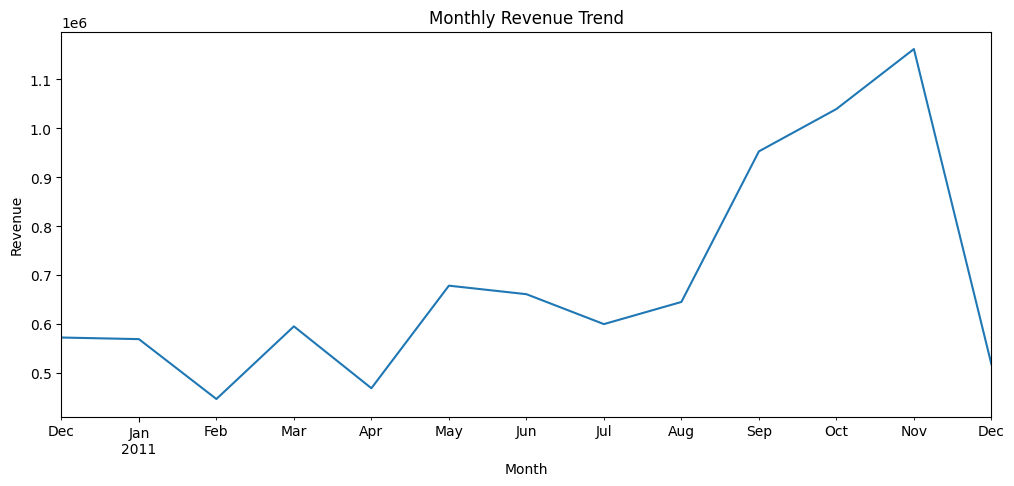

In [24]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()
monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.savefig('../dashboard/monthly_sales.png')
plt.show()

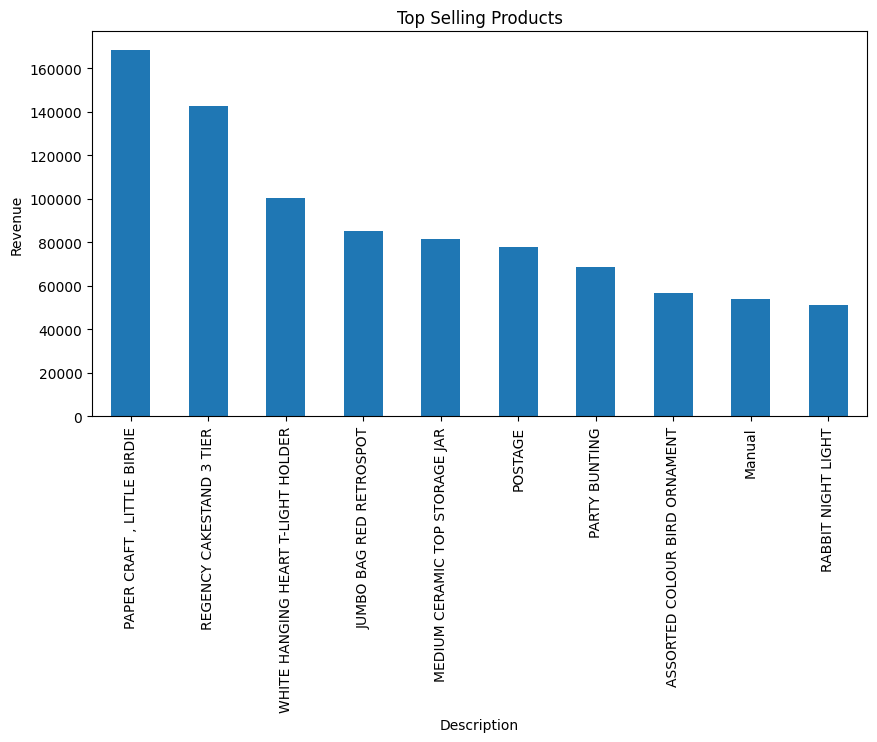

In [25]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top Selling Products")
plt.ylabel("Revenue")
plt.savefig('../dashboard/top_products.png')
plt.show()


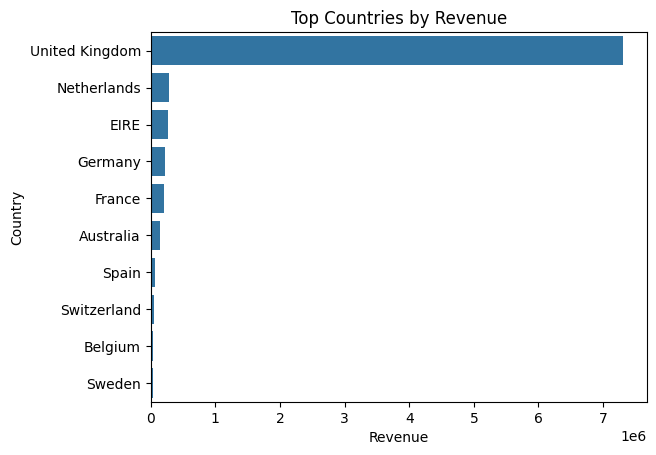

In [26]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title("Top Countries by Revenue")
plt.xlabel("Revenue")
plt.savefig('../dashboard/country_sales.png')
plt.show()
